Part 1: Decision Tree using Information Gain (Entropy) - No Pruning
Training Metrics:
     error: 0.0006
  accuracy: 0.9994
        f1: 0.9993
       auc: 1.0000

Testing Metrics:
     error: 0.0765
  accuracy: 0.9235
        f1: 0.9060
       auc: 0.9189
Part 2: Decision Tree using Gini Index - No Pruning
Training Metrics:
     error: 0.0006
  accuracy: 0.9994
        f1: 0.9993
       auc: 1.0000

Testing Metrics:
     error: 0.0851
  accuracy: 0.9149
        f1: 0.8977
       auc: 0.9154

Combined Metrics Table:
  Model Dataset    Error  Accuracy  F1 Score      AUC
Entropy   Train 0.000580  0.999420  0.999252 0.999999
Entropy    Test 0.076455  0.923545  0.905983 0.918949
   Gini   Train 0.000580  0.999420  0.999252 0.999999
   Gini    Test 0.085143  0.914857  0.897704 0.915371
Part 3: Depth Pruning Results
Best depth based on minimum test error: 17
Minimum test error: 0.0747


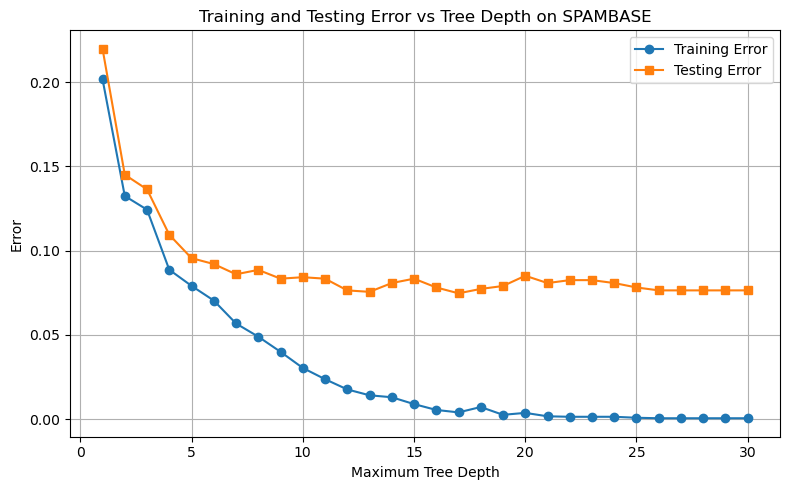

Part 3: Best Pruned Tree (max_depth=17)
Training Metrics:
     error: 0.0041
  accuracy: 0.9959
        f1: 0.9947
       auc: 0.9998

Testing Metrics:
     error: 0.0747
  accuracy: 0.9253
        f1: 0.9079
       auc: 0.9205


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from sklearn.model_selection import train_test_split

df = pd.read_csv("spambase.data", header=None)

# Split into features and labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Split into train/test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

def compute_metrics(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    accuracy = accuracy_score(y, y_pred)
    error = 1 - accuracy
    f1 = f1_score(y, y_pred)
    auc = roc_auc_score(y, y_prob)

    return {
        "error": error,
        "accuracy": accuracy,
        "f1": f1,
        "auc": auc
    }

def print_metrics(title, train_metrics, test_metrics):
    print(title)
    

    print("Training Metrics:")
    for key, value in train_metrics.items():
        print(f"{key:>10}: {value:.4f}")

    print("\nTesting Metrics:")
    for key, value in test_metrics.items():
        print(f"{key:>10}: {value:.4f}")

def metrics_table(train_metrics, test_metrics, model_name):
    return pd.DataFrame({
        "Model": [model_name, model_name],
        "Dataset": ["Train", "Test"],
        "Error": [train_metrics["error"], test_metrics["error"]],
        "Accuracy": [train_metrics["accuracy"], test_metrics["accuracy"]],
        "F1 Score": [train_metrics["f1"], test_metrics["f1"]],
        "AUC": [train_metrics["auc"], test_metrics["auc"]]
    })

#1
tree_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

tree_entropy.fit(X_train, y_train)

train_metrics_entropy = compute_metrics(tree_entropy, X_train, y_train)
test_metrics_entropy = compute_metrics(tree_entropy, X_test, y_test)

print_metrics("Part 1: Decision Tree using Information Gain (Entropy) - No Pruning",
              train_metrics_entropy, test_metrics_entropy)

#2
tree_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

tree_gini.fit(X_train, y_train)

train_metrics_gini = compute_metrics(tree_gini, X_train, y_train)
test_metrics_gini = compute_metrics(tree_gini, X_test, y_test)

print_metrics("Part 2: Decision Tree using Gini Index - No Pruning",
              train_metrics_gini, test_metrics_gini)

#display all metrics in one table
results_df = pd.concat([
    metrics_table(train_metrics_entropy, test_metrics_entropy, "Entropy"),
    metrics_table(train_metrics_gini, test_metrics_gini, "Gini")
], ignore_index=True)

print("\nCombined Metrics Table:")
print(results_df.to_string(index=False))

#3
depths = range(1, 31)

train_errors = []
test_errors = []

for depth in depths:
    model = DecisionTreeClassifier(
        criterion="entropy",   
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_error = 1 - accuracy_score(y_train, train_pred)
    test_error = 1 - accuracy_score(y_test, test_pred)

    train_errors.append(train_error)
    test_errors.append(test_error)

# Find best depth based on lowest test error
best_depth = depths[np.argmin(test_errors)]
best_test_error = min(test_errors)


print("Part 3: Depth Pruning Results")
print(f"Best depth based on minimum test error: {best_depth}")
print(f"Minimum test error: {best_test_error:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(depths, train_errors, marker='o', label='Training Error')
plt.plot(depths, test_errors, marker='s', label='Testing Error')
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Error")
plt.title("Training and Testing Error vs Tree Depth on SPAMBASE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Train final recommended model at best depth
best_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=best_depth,
    random_state=42
)

best_model.fit(X_train, y_train)

best_train_metrics = compute_metrics(best_model, X_train, y_train)
best_test_metrics = compute_metrics(best_model, X_test, y_test)

print_metrics(f"Part 3: Best Pruned Tree (max_depth={best_depth})",
              best_train_metrics, best_test_metrics)


Random Forest (T = 10)
Train:
  accuracy: 0.9957, f1: 0.9944, auc: 0.9999
Test:
  accuracy: 0.9461, f1: 0.9329, auc: 0.9818

Random Forest (T = 50)
Train:
  accuracy: 0.9994, f1: 0.9993, auc: 1.0000
Test:
  accuracy: 0.9583, f1: 0.9482, auc: 0.9884

Random Forest (T = 100)
Train:
  accuracy: 0.9994, f1: 0.9993, auc: 1.0000
Test:
  accuracy: 0.9583, f1: 0.9482, auc: 0.9879

Random Forest (T = 500)
Train:
  accuracy: 0.9994, f1: 0.9993, auc: 1.0000
Test:
  accuracy: 0.9583, f1: 0.9483, auc: 0.9876


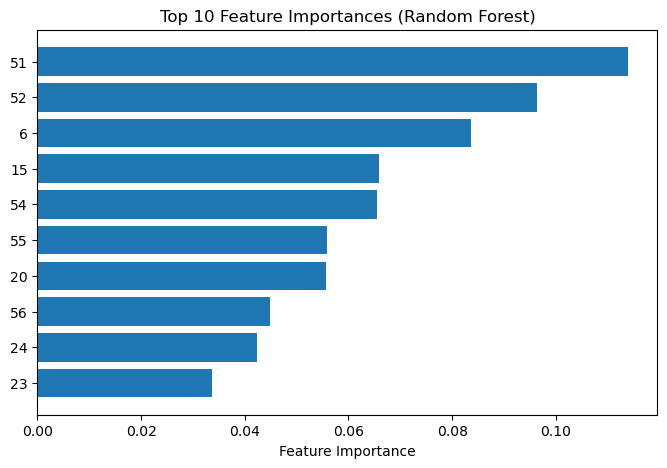

In [3]:
from sklearn.ensemble import RandomForestClassifier

# Helper function
def compute_metrics(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    auc = roc_auc_score(y, y_prob)

    return acc, f1, auc

T_values = [10, 50, 100, 500]

results = []

for T in T_values:
    rf = RandomForestClassifier(
        n_estimators=T,
        random_state=42
    )
    rf.fit(X_train, y_train)

    train_acc, train_f1, train_auc = compute_metrics(rf, X_train, y_train)
    test_acc, test_f1, test_auc = compute_metrics(rf, X_test, y_test)

    print(f"\nRandom Forest (T = {T})")
    print("Train:")
    print(f"  accuracy: {train_acc:.4f}, f1: {train_f1:.4f}, auc: {train_auc:.4f}")
    print("Test:")
    print(f"  accuracy: {test_acc:.4f}, f1: {test_f1:.4f}, auc: {test_auc:.4f}")

    results.append((T, train_acc, train_f1, train_auc, test_acc, test_f1, test_auc))

# Use best 
best_rf = RandomForestClassifier(n_estimators=500, random_state=42)
best_rf.fit(X_train, y_train)

importances = best_rf.feature_importances_

# Plot top 10 features
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), indices)
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()


AdaBoost (T = 10)
Train:
  accuracy: 0.9238, f1: 0.9002, auc: 0.9693
Test:
  accuracy: 0.9227, f1: 0.9029, auc: 0.9688

AdaBoost (T = 50)
Train:
  accuracy: 0.9467, f1: 0.9308, auc: 0.9896
Test:
  accuracy: 0.9348, f1: 0.9196, auc: 0.9776

AdaBoost (T = 100)
Train:
  accuracy: 0.9574, f1: 0.9448, auc: 0.9938
Test:
  accuracy: 0.9435, f1: 0.9312, auc: 0.9811

AdaBoost (T = 500)
Train:
  accuracy: 0.9899, f1: 0.9869, auc: 0.9996
Test:
  accuracy: 0.9374, f1: 0.9242, auc: 0.9768


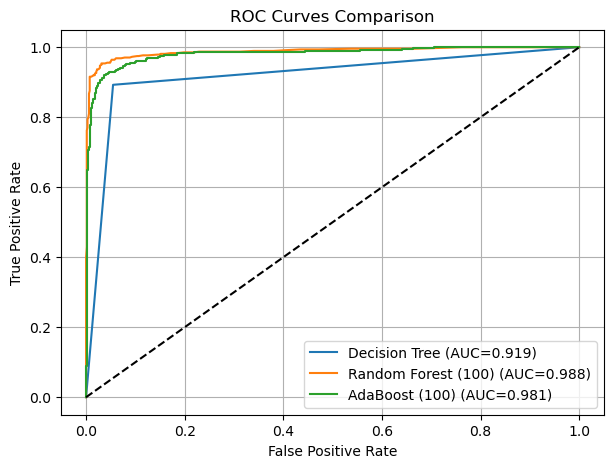

In [12]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import roc_curve

def compute_metrics(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    auc = roc_auc_score(y, y_prob)

    return acc, f1, auc

T_values = [10, 50, 100, 500]

for T in T_values:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=T,
        random_state=42
    )

    ada.fit(X_train, y_train)

    train_acc, train_f1, train_auc = compute_metrics(ada, X_train, y_train)
    test_acc, test_f1, test_auc = compute_metrics(ada, X_test, y_test)

    print(f"\nAdaBoost (T = {T})")
    print("Train:")
    print(f"  accuracy: {train_acc:.4f}, f1: {train_f1:.4f}, auc: {train_auc:.4f}")
    print("Test:")
    print(f"  accuracy: {test_acc:.4f}, f1: {test_f1:.4f}, auc: {test_auc:.4f}")
    
# Decision Tree
dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt.fit(X_train, y_train)

# Random Forest (100 trees)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# AdaBoost (100 classifiers)
ada_100 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)
ada_100.fit(X_train, y_train)

# Plot ROC curves
plt.figure(figsize=(7,5))

models = {
    "Decision Tree": dt,
    "Random Forest (100)": rf,
    "AdaBoost (100)": ada_100
}

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.grid(True)
plt.show()